In [1]:
import pandas as pd

# Load the datasets
df1 = pd.read_csv('taxable-companies-by-resident-type.csv')
df2 = pd.read_csv('taxable-companies-by-resident-type-and-chargeable-income-group.csv')

# Display the first few rows and info
print("Dataset 1 (resident type) head:")
print(df1.head())
print(df1.info())

print("\nDataset 2 (income group) head:")
print(df2.head())
print(df2.info())

Dataset 1 (resident type) head:
   year_of_assessment     resident_type  no_of_companies  chargeable_income  \
0                2005  Non-Tax Resident             1351               5213   
1                2005      Tax Resident            26023              34574   
2                2006  Non-Tax Resident             1449               5916   
3                2006      Tax Resident            29392              40517   
4                2007  Non-Tax Resident             1566               6640   

   net_tax_assessed  
0               731  
1              6108  
2               893  
3              6928  
4               948  
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   year_of_assessment  30 non-null     int64
 1   resident_type       30 non-null     str  
 2   no_of_companies     30 non-null     int64
 3   chargeable_income   30 non-nul

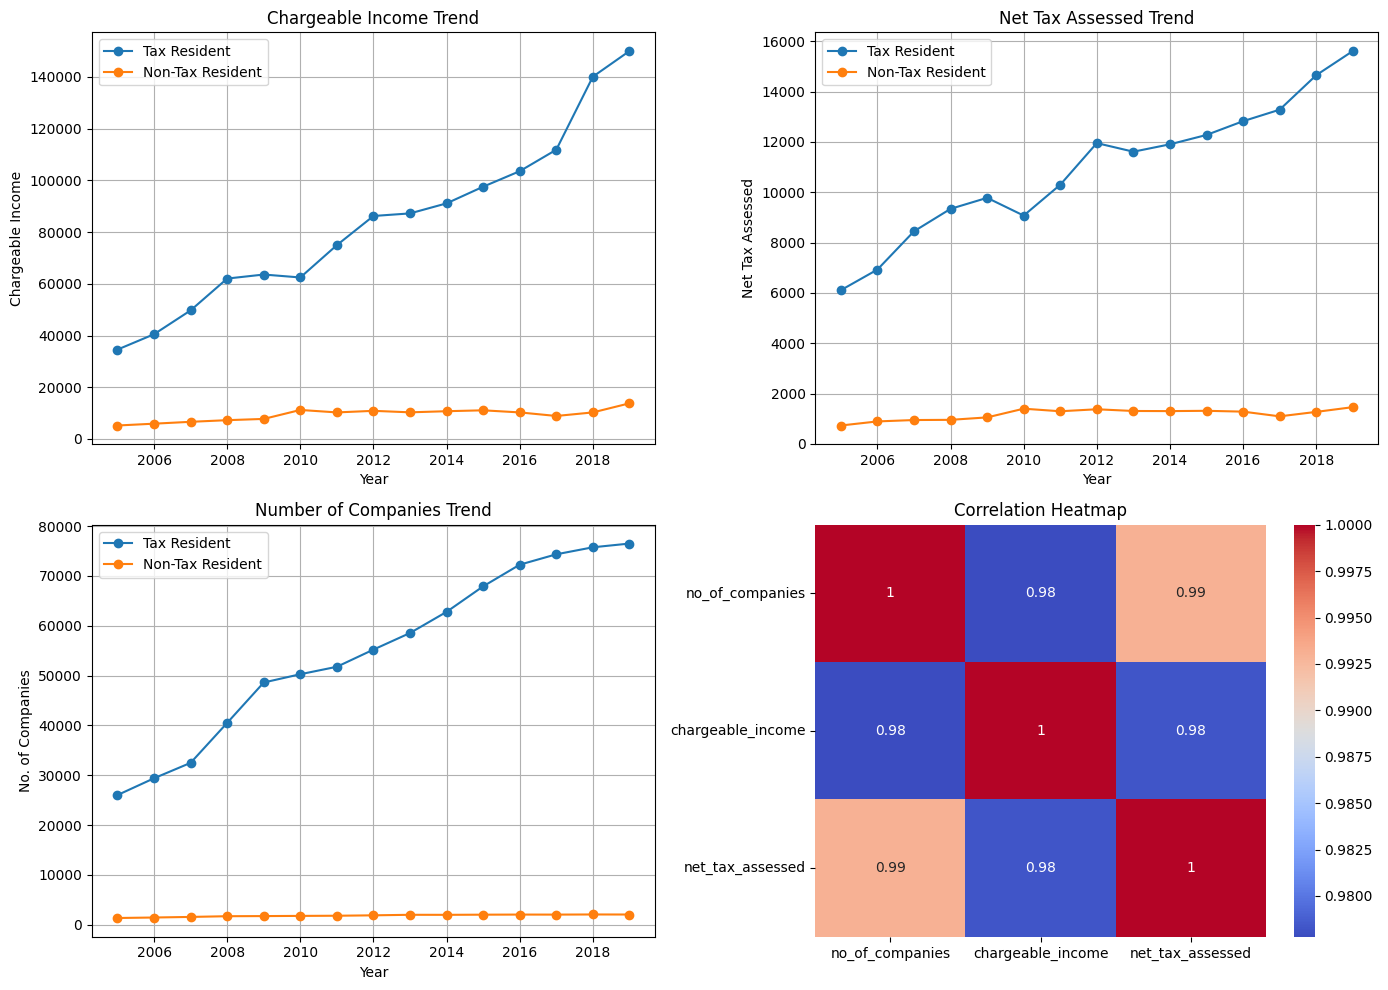

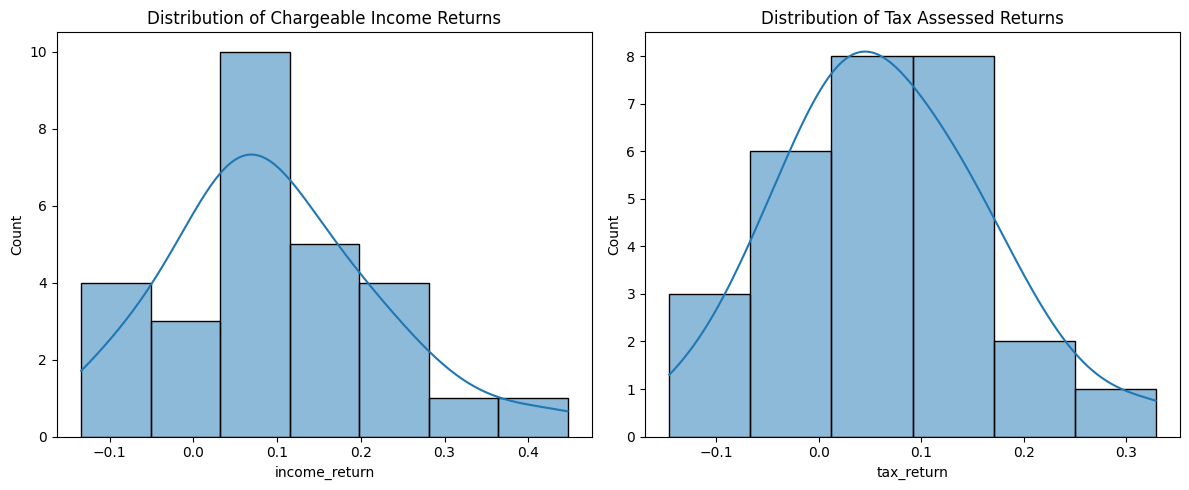

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Trends & Volume
# Filter df1 to separate by resident_type
tax_resident = df1[df1['resident_type'] == 'Tax Resident']
non_tax_resident = df1[df1['resident_type'] == 'Non-Tax Resident']

# Plotting Trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trend: Chargeable Income
axes[0, 0].plot(tax_resident['year_of_assessment'], tax_resident['chargeable_income'], label='Tax Resident', marker='o')
axes[0, 0].plot(non_tax_resident['year_of_assessment'], non_tax_resident['chargeable_income'], label='Non-Tax Resident', marker='o')
axes[0, 0].set_title('Chargeable Income Trend')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Chargeable Income')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Trend: Net Tax Assessed
axes[0, 1].plot(tax_resident['year_of_assessment'], tax_resident['net_tax_assessed'], label='Tax Resident', marker='o')
axes[0, 1].plot(non_tax_resident['year_of_assessment'], non_tax_resident['net_tax_assessed'], label='Non-Tax Resident', marker='o')
axes[0, 1].set_title('Net Tax Assessed Trend')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Net Tax Assessed')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Volume: Number of Companies
axes[1, 0].plot(tax_resident['year_of_assessment'], tax_resident['no_of_companies'], label='Tax Resident', marker='o')
axes[1, 0].plot(non_tax_resident['year_of_assessment'], non_tax_resident['no_of_companies'], label='Non-Tax Resident', marker='o')
axes[1, 0].set_title('Number of Companies Trend')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('No. of Companies')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 3. Correlation Heat Map
# Use numerical columns only
numeric_cols = df1[['no_of_companies', 'chargeable_income', 'net_tax_assessed']]
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('trends_analysis.png')

# 4. Return Distribution (Percentage Change year-over-year)
# Calculate pct change for chargeable_income and net_tax_assessed per resident_type
df1_sorted = df1.sort_values(['resident_type', 'year_of_assessment'])
df1_sorted['income_return'] = df1_sorted.groupby('resident_type')['chargeable_income'].pct_change()
df1_sorted['tax_return'] = df1_sorted.groupby('resident_type')['net_tax_assessed'].pct_change()

# Plotting Distribution
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df1_sorted['income_return'].dropna(), kde=True, ax=axes2[0])
axes2[0].set_title('Distribution of Chargeable Income Returns')
sns.histplot(df1_sorted['tax_return'].dropna(), kde=True, ax=axes2[1])
axes2[1].set_title('Distribution of Tax Assessed Returns')
plt.tight_layout()
plt.savefig('returns_distribution.png')